# 1D Fokker–Planck: four periodic experiments

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tommasocortopassi/fokker_planck_1d_solver/blob/master/fokker_planck_experiments.ipynb)

The animations below are pre-rendered GIFs, so they display without
running anything. Open the notebook in Colab (badge above) to re-run it
and get the interactive versions instead.

This notebook employs the three solvers of the `fp1d` package on the
`periodic` 1D Fokker–Planck equation

$$
\partial_t p = -\partial_x\big(b(x,t)\,p\big) + \partial_x^2\big(D(x,t)\,p\big),
$$

on the fixed domain $[-5, 5]$, up to $T = 10$ (a longer final time adds
nothing here: every experiment has already made its point by then).

The three methods compared throughout are:

- **Forward Euler**: explicit finite volume (conditionally stable);
- **Backward Euler**: implicit finite volume (unconditionally stable);
- **Euler–Maruyama**: the Lagrangian particle/SDE method, whose density
  is recovered as a normalized histogram of $10^5$ trajectories.

All boundary conditions are **periodic**. Every experiment is presented
graphically only: an animation of the time-evolving numerical density
(with the exact solution overlaid, if known), followed by a
final-time comparison plot.

| # | Regime | Known solution used to validate                   |
|---|---|---------------------------------------------------|
| 1 | Diffusion only, $b=0,\ D=1$ | $p = \frac1L(1 + \frac12 e^{-D k^2 t}\cos (kx))$  |
| 2 | Combined-CFL failure | stability demonstration (no exact solution)   |
| 3 | Drift only, $D=0$, $\lambda=1$ | pure translation $p_0(x - bt)$                    |
| 4 | Time-dependent $D(t)$ | $p = \frac1L(1 + \frac12 e^{-k^2 A(t)}\cos (kx))$, with $A(t)= \int_0 ^t D(s) ds$. |


In [1]:
###
# Fetch the package from GitHub when running on Colab.
# Skipped automatically when the notebook is run locally from the repo root.
###

import os
if not os.path.exists('fp1d'):
    !git clone -q https://github.com/tommasocortopassi/fokker_planck_1d_solver.git
    %cd fokker_planck_1d_solver
    !pip install -q -r requirements.txt


In [2]:
import sys, os
# Make the fp1d package importable whether the notebook is launched from
# the project root or from a subfolder next to it.
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

from fp1d import solve                      # the package's public entry point
from fp1d.grid import make_grid              # only to inspect dx/dt stability
from fp1d.diagnostics import sample_diagnostics

# Importing the package pulls in `fp1d.visualization`, which forces
# matplotlib's Agg backend - the GUI plots from a worker thread, where
# touching an interactive backend is unsafe. Agg writes files but draws
# nothing inline, so the notebook's own figures have to be switched back
# on explicitly, and only after the import above.
%matplotlib inline

# Animations are written to docs/img/*.gif and shown via markdown cells, so
# the committed notebook stays small enough for GitHub to render inline.
# Set ANIMATE_INLINE = True to get interactive JS animations instead
# (convenient when running locally or on Colab; do NOT commit the result).
ANIMATE_INLINE = False
os.makedirs('docs/img', exist_ok=True)
plt.rcParams['animation.html'] = 'jshtml'
plt.rcParams['figure.dpi'] = 100

DOMAIN = (-5.0, 5.0)
L = DOMAIN[1] - DOMAIN[0]          # domain length, 10
K = 2.0 * np.pi / L               # lowest periodic wavenumber
print(f'Domain {DOMAIN}, length L = {L}, fundamental wavenumber k = {K:.5f}')

# The initial density, written twice: once as a Python function (used by
# the exact solutions below) and once as a string for `solve`, whose
# expression sandbox sees only `x` and numpy - so K and L are baked in as
# literals rather than referenced as names.
COSINE_EXPR = f'(1 + 0.5*np.cos({K}*x))/{L}'
print('initial condition passed to solve():', COSINE_EXPR)


Domain (-5.0, 5.0), length L = 10.0, fundamental wavenumber k = 0.62832
initial condition passed to solve(): (1 + 0.5*np.cos(0.6283185307179586*x))/10.0


## Shared helpers

Two groups of utilities used by every experiment:

- `cosine_ic` builds the normalized periodic density
  $p_0(x) = \frac1L(1 + \frac12\cos(kx))$: non-negative (minimum
  $\frac1{2L}>0$), integrates to 1, sampleable for Euler–Maruyama, and
  with a closed-form evolution under both pure diffusion and pure
  translation.
- `run_all_three` runs the three solvers with a shared configuration;
  `animate_density` and `final_comparison_plot` handle the (purely
  graphical) output. Each experiment below is then just "set
  coefficients, run, plot".


In [3]:
def cosine_ic(x):
    """Normalized periodic density (1 + 0.5 cos kx)/L on the domain."""
    return (1.0 + 0.5 * np.cos(K * x)) / L


def run_all_three(dx, dt, total_time, save_times, drift, diffusion,
                  n_trials=100_000, seed=0, methods=('FE', 'BE', 'EM'),
                  bc='periodic', custom_expr=None, on_warning='warn'):
    """Run the requested subset of the three solvers on one problem.

    Everything goes through `fp1d.solve`, the same entry point the GUI
    uses, so these cells exercise the package exactly as an outside user
    would - grid construction, initial condition and boundary handling
    included. Returns a dict keyed by 'FE' / 'BE' / 'EM' -> SolverResult.
    All share the same domain, dx, dt and save_times, so their outputs are
    directly comparable frame by frame.

    `on_warning` is forwarded to `solve`. It matters only in Experiment 2,
    which deliberately violates the explicit stability condition: the
    default `'warn'` would fire the pre-flight check on every Forward
    Euler call there, so that one experiment passes `'ignore'` and says
    in its own text that the blow-up is the intended result.
    """
    method_names = {'FE': 'forward euler',
                    'BE': 'backward euler',
                    'EM': 'euler-maruyama'}
    out = {}
    for key in methods:
        run = solve(method=method_names[key],
                    drift=drift, diffusion=diffusion,
                    left=DOMAIN[0], right=DOMAIN[1], dx=dx,
                    total_time=total_time, dt=dt, save_times=save_times,
                    bc=bc, initial_condition='custom',
                    custom_expr=custom_expr or COSINE_EXPR,
                    trials=n_trials, seed=seed, on_warning=on_warning)
        out[key] = run.result
    return out


# Consistent per-method plot styling across every experiment.
STYLE = {
    'FE': dict(color='tab:blue',   label='Forward Euler'),
    'BE': dict(color='tab:green',  label='Backward Euler'),
    'EM': dict(color='tab:orange', label='Euler–Maruyama ($10^5$)'),
}
EXACT_STYLE = dict(color='black', ls='--', lw=2, label='Exact')


def animate_density(results, save_as, exact_fn=None, title='', ymargin=0.15,
                    max_frames=45, yscale='linear', ylim=None,
                    linthresh=1.0):
    """Animate the recorded frames of one or more solver results.

    `results` is the dict returned by `run_all_three`. Each method's own
    recorded `frames`/`frame_times` are used (captured during
    integration, so this is genuine playback, not interpolation).

    To keep the embedded animation light, at most `max_frames` frames are
    shown, subsampled evenly across the run (the underlying solve still
    uses the full time step; this only thins what gets drawn).

    `exact_fn(x, t) -> density` is overlaid as a dashed black line when
    given. `yscale='symlog'` (with `linthresh`) is used for the
    combined-CFL blow-up, where the density swings symmetrically to
    +/- 1e84: a symmetric-log axis keeps both the tiny early profile and
    the exploding checkerboard on screen at once.

    Writes `docs/img/<save_as>` and returns None; with
    `ANIMATE_INLINE = True` it instead returns an IPython HTML animation
    for inline display and writes nothing.
    """
    methods = list(results)
    ref = results[methods[0]]
    x = ref.x

    n_avail = min(len(results[m].frame_times) for m in methods)
    stride = max(1, n_avail // max_frames)
    idx = list(range(0, n_avail, stride))
    frame_times = ref.frame_times

    if ylim is not None:
        ylo, yhi = ylim
    else:
        # y-limits from the union of everything shown, with a margin.
        ymax = max(float(np.max(results[m].frames[:n_avail])) for m in methods)
        ymin = min(float(np.min(results[m].frames[:n_avail])) for m in methods)
        if exact_fn is not None:
            ex_all = np.array([exact_fn(x, frame_times[i]) for i in idx])
            ymax = max(ymax, float(np.max(ex_all)))
            ymin = min(ymin, float(np.min(ex_all)))
        span = max(ymax - ymin, 1e-9)
        ylo, yhi = ymin - ymargin * span, ymax + ymargin * span

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    if yscale == 'symlog':
        ax.set_yscale('symlog', linthresh=linthresh)
    lines = {}
    for m in methods:
        (lines[m],) = ax.plot([], [], lw=2, **STYLE[m])
    exact_line = None
    if exact_fn is not None:
        (exact_line,) = ax.plot([], [], **EXACT_STYLE)

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel('$x$')
    ax.set_ylabel('density $p(x,t)$')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    time_text = ax.set_title('')

    def init():
        for m in methods:
            lines[m].set_data([], [])
        if exact_line is not None:
            exact_line.set_data([], [])
        # Must return the same artists as `update`, or enabling blitting
        # later would silently stop redrawing the exact-solution line.
        artists = list(lines.values())
        if exact_line is not None:
            artists.append(exact_line)
        return tuple(artists)

    def update(frame_i):
        t = frame_times[frame_i]
        for m in methods:
            lines[m].set_data(x, results[m].frames[frame_i])
        if exact_line is not None:
            exact_line.set_data(x, exact_fn(x, t))
        time_text.set_text(f'{title}   (t = {t:.3g})')
        artists = list(lines.values())
        if exact_line is not None:
            artists.append(exact_line)
        return tuple(artists)

    anim = animation.FuncAnimation(fig, update, frames=idx,
                                   init_func=init, blit=False, interval=90)
    plt.close(fig)
    if ANIMATE_INLINE:
        return HTML(anim.to_jshtml())
    # Write a GIF instead of embedding every frame as base64 in the .ipynb:
    # the markdown cell below points at the file, so the committed notebook
    # carries a path rather than a few tens of MB of encoded frames.
    path = os.path.join('docs', 'img', save_as)
    anim.save(path, writer='pillow', fps=9, dpi=68)
    print(f'saved {path}')


def final_comparison_plot(results, exact_fn=None, title='',
                          t_final=None, extra_note=None):
    """Static final-time overlay of every method (+ exact if known)."""
    methods = list(results)
    ref = results[methods[0]]
    x = ref.x
    if t_final is None:
        t_final = float(ref.save_times[-1])

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for m in methods:
        ax.plot(x, results[m].snapshots[-1], lw=2, **STYLE[m])
    if exact_fn is not None:
        ax.plot(x, exact_fn(x, t_final), **EXACT_STYLE)
    ax.set_xlabel('$x$')
    ax.set_ylabel('density $p(x,t)$')
    ax.set_title(f'{title}   —   final time t = {t_final:.3g}')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    if extra_note:
        ax.text(0.02, 0.03, extra_note, transform=ax.transAxes, fontsize=9,
                color='dimgray', va='bottom')
    plt.show()


## Experiment 1 — diffusion only ($b=0$, $D=1$)

The pure heat equation $\partial_t p = D\,\partial_x^2 p$ on the periodic
domain. With the initial density
$p_0(x) = \frac{1}{L}\left(1+\tfrac12\cos (kx)\right)$ ($k = 2\pi/L$), only the
cosine mode evolves, and it decays exactly as $e^{-D k^2 t}$:

$$
p(x,t) = \frac{1}{L}\Big(1 + \tfrac12\,e^{-D k^2 t}\cos (kx)\Big).
$$

With $\Delta x, \Delta t$ inside the stability bound
($\lambda + 2\mu \le 1$, here $\lambda = 0$ so simply $\mu \le \tfrac12$),
all three methods should track this exact curve. The Euler–Maruyama
density is a normalized histogram of $10^5$ trajectories, so it carries
sampling noise. The relevant scale is the standard error of a histogram
bin, $\sqrt{p/(N\,\Delta x)}\approx 4\times10^{-3}$ here, which is what the
RMS discrepancy measures; the *largest* deviation across the 200 cells is
a few times that, so the visible error against the exact curve is
$O(10^{-2})$. This is the expected price of the particle method, not a
defect.


In [4]:
# Experiment 1 — diffusion only: b = 0, D = 1.
# Exact periodic solution of p_t = D p_xx with p0 = (1 + 0.5 cos kx)/L:
# only the cos-mode decays, as exp(-D k^2 t), so
#     p(x,t) = (1 + 0.5 e^{-D k^2 t} cos kx) / L.
D = 1.0
# The grid is built here only to feed `sample_diagnostics` below; the
# cell centres used for plotting are taken from the solver result, so
# there is one source of truth for the x-axis.
grid1, _ = make_grid(DOMAIN[0], DOMAIN[1], 0.05)

drift1 = lambda x, t=0.0: np.zeros_like(x)
diffusion1 = lambda x, t=0.0: D * np.ones_like(x)


def exact1(x, t):
    return (1.0 + 0.5 * np.exp(-D * K**2 * t) * np.cos(K * x)) / L


# Stability (b = 0): the combined condition reduces to 2*mu <= 1, i.e.
# mu = D dt/dx^2 <= 1/2. With dx = 0.05, that means dt <= 0.5*dx^2/D =
# 0.00125; we take dt = 0.001, comfortably inside the bound.
dt1 = 0.001
diag1 = sample_diagnostics(grid1, drift1, diffusion1, dt1, total_time=10.0)
print(f"dx = {grid1.dx}, dt = {dt1}")
print(f"lambda = {diag1['lambda']:.4f}, mu = {diag1['mu']:.4f}, "
      f"lambda + 2*mu = {diag1['combined_CFL']:.4f}  "
      f"(stable for Forward Euler: {diag1['stable']})")

save_times1 = [0.0, 1.0, 2.0, 5.0, 10.0]
results1 = run_all_three(grid1.dx, dt1, total_time=10.0,
                         save_times=save_times1,
                         drift=drift1, diffusion=diffusion1,
                         n_trials=100_000, seed=0)
x1 = results1['FE'].x
print("done:", {m: results1[m].snapshots.shape for m in results1})


dx = 0.05, dt = 0.001
lambda = 0.0000, mu = 0.4000, lambda + 2*mu = 0.8000  (stable for Forward Euler: True)


done: {'FE': (5, 200), 'BE': (5, 200), 'EM': (5, 200)}


In [5]:
animate_density(results1, 'exp1_diffusion.gif', exact_fn=exact1,
                title='Exp 1 — diffusion only (b=0, D=1)')


saved docs/img/exp1_diffusion.gif


![Experiment 1 - diffusion only](docs/img/exp1_diffusion.gif)


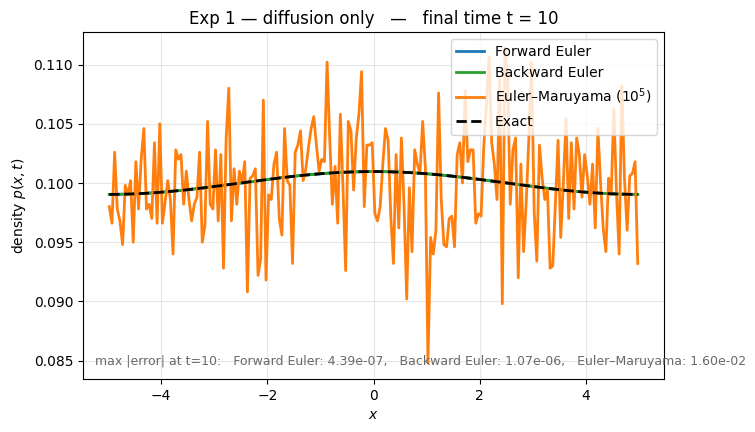

In [6]:
# Final-time comparison, plus the max error of each method vs the exact
# solution at t = 10 (printed as a caption, results stay graphical).
errs1 = {m: float(np.max(np.abs(results1[m].snapshots[-1] - exact1(x1, 10.0))))
         for m in results1}
note1 = "max |error| at t=10:   " + ",   ".join(
    f"{STYLE[m]['label'].split(' (')[0]}: {errs1[m]:.2e}" for m in results1)
final_comparison_plot(results1, exact_fn=exact1,
                      title='Exp 1 — diffusion only', extra_note=note1)


## Experiment 2 — combined-CFL failure

Here the point is a stability subtlety: the explicit scheme is governed by
the *combined* condition $\lambda + 2\mu \le 1$, **not** by the two
separate conditions $\lambda \le 1$ and $\mu \le \tfrac12$ holding
individually. We pick constant coefficients giving

$$
\lambda = \frac{|b|\,\Delta t}{\Delta x} = 0.7 \le 1, \qquad
\mu = \frac{D\,\Delta t}{\Delta x^2} = 0.3 \le \tfrac12,
$$

so each separate CFL is satisfied, yet
$\lambda + 2\mu = 0.7 + 0.6 = 1.3 > 1$. Forward Euler must therefore
diverge, while Backward Euler (unconditionally stable) and Euler–Maruyama
(no CFL constraint at all) remain well-behaved.

The Forward Euler magnitude reaches $\sim 10^{84}$. We visualize this on a
**symmetric-log** axis, which keeps both the tiny initial profile and the
exploding density on screen at once. The animation shows all three
methods together: Forward Euler erupting, Backward Euler and
Euler–Maruyama staying flat at $O(0.1)$, followed by the peak magnitude
$\max_x|p(x,t)|$ vs. time on a log scale (a straight line there is
geometric growth).

**Where the instability comes from is worth stating precisely.** The mode
that grows is the shortest one the grid can carry, the cell-to-cell
checkerboard $p_j \propto (-1)^j$ at the Nyquist wavenumber — and its
amplitude in the initial data is *exactly zero*, since
$p_0 = \frac1L(1+\frac12\cos kx)$ contains only the modes $0$ and $\pm1$.
So there is nothing physical for the scheme to amplify: the checkerboard
is seeded purely by floating-point round-off, at a level of order
$10^{-16}$, and then multiplied by roughly $1.5$ per step for $500$
steps.

The practical consequence is that the *exponent* below is reproducible
(it is set by the growth rate and the number of steps) while the leading
digits are not. Perturbing $b$ by one unit in the last place changes the
final peak by tens of percent, because it changes the round-off seed. Do
not read `1.64e+84` as a number this cell would print on another machine;
read it as "about $10^{84}$, i.e. catastrophically diverged".

In [7]:
# Experiment 2 — combined-CFL failure.
# Constant b, D chosen so each *separate* CFL is satisfied but the
# combined explicit condition fails:
#     lambda = |b| dt/dx = 0.7   <= 1     (advective CFL: OK)
#     mu     = D   dt/dx^2 = 0.3  <= 1/2   (diffusive CFL: OK)
#     lambda + 2*mu = 0.7 + 0.6 = 1.3  > 1  (combined: FAILS)
# Forward Euler must therefore eventually blow up; Backward Euler
# (unconditionally stable) must not. Euler-Maruyama has no CFL at all -
# its step is a drifted Gaussian regardless - so it stays well-behaved.
dx2 = 0.1
dt2 = 0.02
grid2, _ = make_grid(DOMAIN[0], DOMAIN[1], dx2)

b_const2 = 0.7 * dx2 / dt2          # gives lambda = 0.7
D_const2 = 0.3 * dx2**2 / dt2       # gives mu = 0.3
drift2 = lambda x, t=0.0: b_const2 * np.ones_like(x)
diffusion2 = lambda x, t=0.0: D_const2 * np.ones_like(x)

diag2 = sample_diagnostics(grid2, drift2, diffusion2, dt2, total_time=10.0)
print(f"b = {b_const2:.3f}, D = {D_const2:.3f}, dx = {dx2}, dt = {dt2}")
print(f"lambda = {diag2['lambda']:.3f}  (<= 1 separately: {diag2['lambda'] <= 1})")
print(f"mu     = {diag2['mu']:.3f}  (<= 0.5 separately: {diag2['mu'] <= 0.5})")
print(f"lambda + 2*mu = {diag2['combined_CFL']:.3f}  "
      f"(combined stable: {diag2['stable']})")

# T = 10 is already plenty for the instability to reach astronomical
# magnitude, but the growth is geometric so we sample a few interior
# times to watch it take off.
save_times2 = [0.0, 1.0, 2.0, 3.0, 5.0, 10.0]
# `solve` runs a pre-flight stability check and warns when Forward Euler
# cannot survive the requested dt. Here that instability is the entire
# point of the experiment, so the warning is suppressed rather than
# printed five times - see the text above.
results2 = run_all_three(grid2.dx, dt2, total_time=10.0,
                         save_times=save_times2,
                         drift=drift2, diffusion=diffusion2,
                         n_trials=100_000, seed=0, on_warning='ignore')

x2 = results2['FE'].x

# Peak magnitude over time makes the FE blow-up unmistakable.
for m in results2:
    peaks = [float(np.max(np.abs(s))) for s in results2[m].snapshots]
    print(f"{m} max|p| at saved times:",
          ", ".join(f"{p:.2e}" for p in peaks))


b = 3.500, D = 0.150, dx = 0.1, dt = 0.02
lambda = 0.700  (<= 1 separately: True)
mu     = 0.300  (<= 0.5 separately: True)
lambda + 2*mu = 1.300  (combined stable: False)


FE max|p| at saved times: 1.50e-01, 1.46e-01, 9.60e+02, 1.24e+13, 2.25e+33, 1.64e+84
BE max|p| at saved times: 1.50e-01, 1.42e-01, 1.35e-01, 1.29e-01, 1.21e-01, 1.09e-01
EM max|p| at saved times: 1.54e-01, 1.49e-01, 1.45e-01, 1.46e-01, 1.43e-01, 1.32e-01


In [8]:
# The instability is now shown directly: all three methods on a
# SYMMETRIC-log y-axis (linear near 0, log further out, both signs). The
# Forward Euler curve starts flat like the others, then explodes.
# Backward Euler and Euler-Maruyama stay pinned near the bottom, around
# their O(0.1) physical values.
animate_density(results2, 'exp2_blowup.gif', exact_fn=None,
                title='Exp 2 — Forward Euler blow-up (symlog axis)',
                yscale='symlog', linthresh=1.0, ylim=(-1e84, 1e84))


saved docs/img/exp2_blowup.gif


![Experiment 2 - Forward Euler blow-up](docs/img/exp2_blowup.gif)


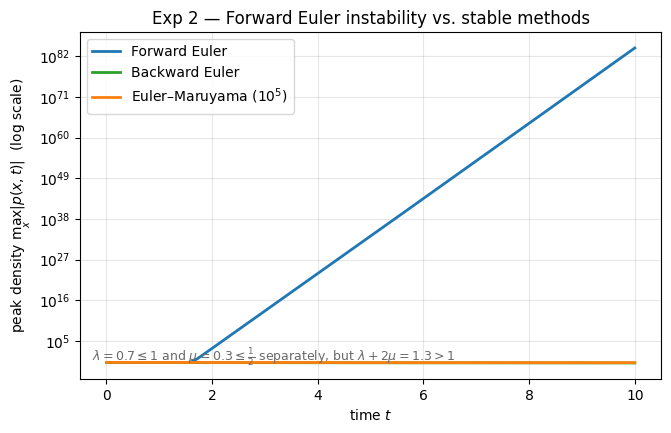

In [9]:
# Forward Euler grows geometrically (a straight line on a log axis = exponential
# growth); Backward Euler and Euler-Maruyama stay O(1).
# We reconstruct a dense magnitude-vs-time trace from the recorded
# animation frames of each method.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for m in results2:
    ft = results2[m].frame_times
    peak = np.max(np.abs(results2[m].frames), axis=1)
    ax.semilogy(ft, peak, lw=2, **STYLE[m])
ax.set_xlabel('time $t$')
ax.set_ylabel(r'peak density $\max_x |p(x,t)|$  (log scale)')
ax.set_title('Exp 2 — Forward Euler instability vs. stable methods')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left')
ax.text(0.02, 0.03,
        r'$\lambda=0.7\leq1$ and $\mu=0.3\leq\frac{1}{2}$ separately, '
        r'but $\lambda+2\mu=1.3>1$',
        transform=ax.transAxes, fontsize=9, color='dimgray', va='bottom')
plt.show()


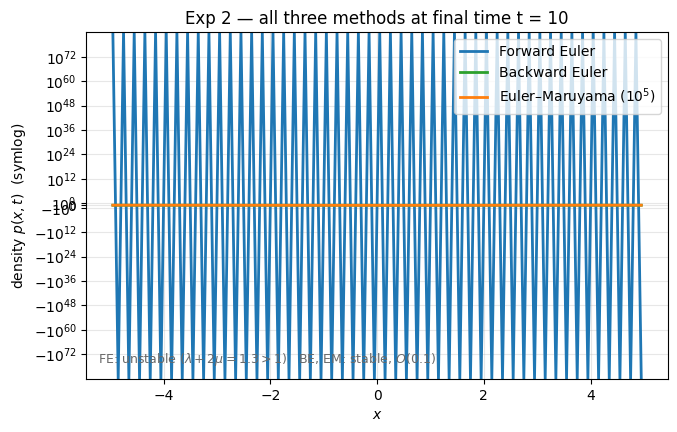

In [10]:
# Final-time snapshot of all three methods on the same log axis: the
# Forward Euler has reached ~1e84, while Backward Euler and
# Euler-Maruyama sit at their physical O(0.1) magnitude near the bottom.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.set_yscale('symlog', linthresh=1.0)
for m in results2:
    ax.plot(x2, results2[m].snapshots[-1], lw=2, **STYLE[m])
ax.set_ylim(-1e84, 1e84)
ax.set_xlabel('$x$')
ax.set_ylabel('density $p(x,t)$  (symlog)')
ax.set_title('Exp 2 — all three methods at final time t = 10')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.text(0.02, 0.03,
        r'FE: unstable ($\lambda+2\mu=1.3>1$)   '
        r'BE, EM: stable, $O(0.1)$',
        transform=ax.transAxes, fontsize=9, color='dimgray', va='bottom')
plt.show()

## Experiment 3 — drift only ($D=0$), Courant number $\lambda = 1$

Pure advection $\partial_t p = -b\,\partial_x p$ with constant $b>0$: the
exact solution is rigid translation, $p(x,t) = p_0(x - bt)$ (wrapped
periodically). Choosing $\Delta t$ so that the Courant number is exactly
$\lambda = b\,\Delta t/\Delta x = 1$, the upwind Forward Euler update

$$
p_i^{n+1} = p_i^n - \lambda\,(p_i^n - p_{i-1}^n) = p_{i-1}^n
$$

becomes a pure one-cell shift — **exact translation with no numerical
diffusion whatsoever**. Backward Euler, at the same $\Delta t$, does not
have this property: it introduces numerical diffusion that visibly damps
the profile as it travels.

The peak-to-peak amplitude is the clean scalar signature: it stays
constant for Forward Euler (and the exact solution), and decays for
Backward Euler. Euler–Maruyama transports the ensemble deterministically
here ($D=0$, so every particle moves by exactly $b\,\Delta t = \Delta x$
per step, one cell), which is why its amplitude is likewise constant in
time to the last digit.

Its *value*, however, sits a few per cent above the exact one, and that
offset is a bias rather than noise: peak-to-peak is a maximum minus a
minimum, and sampling fluctuations push the maximum up and the minimum
down, so the statistic is inflated in one direction. Averaged over
several seeds the excess is about $+8\%$ and never negative. Refining it
away needs more trajectories, not a smaller step.


In [11]:
# Experiment 3 — drift only: D = 0, constant b > 0.
# With the Courant number lambda = b dt/dx set to EXACTLY 1, the upwind
# Forward Euler update p_i^{n+1} = p_i^n - lambda (p_i^n - p_{i-1}^n)
# collapses to p_i^{n+1} = p_{i-1}^n: a pure one-cell shift, i.e. exact
# translation with ZERO numerical diffusion. The exact periodic solution
# is just the initial profile translated at speed b:
#     p(x,t) = p0(x - b t)   (periodic wrap).
# Backward Euler, at the same dt, is not exact: it introduces visible
# numerical diffusion that flattens the profile over time.
b_const3 = 1.0
dx3 = 0.1
grid3, _ = make_grid(DOMAIN[0], DOMAIN[1], dx3)

dt3 = dx3 / b_const3   # Courant number lambda = b*dt/dx = 1 exactly
drift3 = lambda x, t=0.0: b_const3 * np.ones_like(x)
diffusion3 = lambda x, t=0.0: np.zeros_like(x)

print(f"b = {b_const3}, dx = {dx3}, dt = {dt3}, Courant lambda = {b_const3*dt3/dx3:.3f}")


def exact3(x, t):
    # translate then wrap back into [DOMAIN[0], DOMAIN[1]]
    xs = DOMAIN[0] + np.mod(x - b_const3 * t - DOMAIN[0], L)
    return cosine_ic(xs)


save_times3 = [0.0, 2.5, 5.0, 7.5, 10.0]
# Drift-only is pure advection: no diffusion for the SDE, so particles
# move deterministically x -> x + b*dt. Still run 10^5 for consistency.
results3 = run_all_three(grid3.dx, dt3, total_time=10.0,
                         save_times=save_times3,
                         drift=drift3, diffusion=diffusion3,
                         n_trials=100_000, seed=0)

x3 = results3['FE'].x

# Peak-to-peak amplitude is the cleanest scalar signature of numerical
# diffusion: it must stay constant for exact translation (FE, lambda=1)
# and shrink for a diffusive scheme (BE).
for m in results3:
    ptp = [float(np.ptp(s)) for s in results3[m].snapshots]
    print(f"{m} peak-to-peak amplitude at saved times:",
          ", ".join(f"{v:.4f}" for v in ptp))
print(f"exact peak-to-peak (constant): {np.ptp(cosine_ic(x3)):.4f}")


b = 1.0, dx = 0.1, dt = 0.1, Courant lambda = 1.000


FE peak-to-peak amplitude at saved times: 0.1000, 0.1000, 0.1000, 0.1000, 0.1000
BE peak-to-peak amplitude at saved times: 0.1000, 0.0906, 0.0821, 0.0745, 0.0675
EM peak-to-peak amplitude at saved times: 0.1094, 0.1094, 0.1094, 0.1094, 0.1094
exact peak-to-peak (constant): 0.1000


In [12]:
animate_density(results3, 'exp3_advection.gif', exact_fn=exact3,
                title=r'Exp 3 — drift only, Courant $\lambda=1$ '
                      r'(FE exact, BE smears)')


saved docs/img/exp3_advection.gif


![Experiment 3 - drift only, Courant 1](docs/img/exp3_advection.gif)


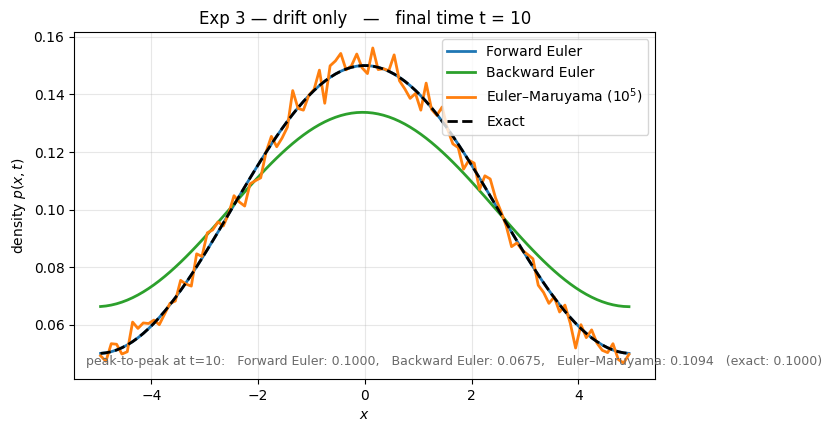

In [13]:
# At the final time the profile has traveled b*T = 10 units = exactly one
# full period, so the exact solution coincides with the initial profile.
# Forward Euler (lambda=1) sits on top of it; Backward Euler is visibly
# damped by numerical diffusion.
amp3 = {m: float(np.ptp(results3[m].snapshots[-1])) for m in results3}
note3 = ("peak-to-peak at t=10:   " +
         ",   ".join(f"{STYLE[m]['label'].split(' (')[0]}: {amp3[m]:.4f}" for m in results3) +
         f"   (exact: {np.ptp(cosine_ic(x3)):.4f})")
final_comparison_plot(results3, exact_fn=exact3,
                      title='Exp 3 — drift only', extra_note=note3)


## Experiment 4 — time-dependent coefficients with a known solution

A genuinely time-dependent problem that still admits a closed-form
periodic solution: pure diffusion with a space-constant but
**time-varying** diffusivity

$$
D(t) = D_0 + D_1 \sin\!\Big(\frac{2\pi t}{P}\Big), \qquad D_0 = 1,\ D_1 = 0.8,\ P = 5,
$$

kept strictly positive. For $\partial_t p = D(t)\,\partial_x^2 p$ the
cosine mode decays by the *accumulated* diffusion
$A(t) = \int_0^t D(s)\,ds$, which has the closed form
$A(t) = D_0 t + \tfrac{D_1 P}{2\pi}\big(1 - \cos\left(\tfrac{2\pi t}{P}\right)\big)$, so

$$
p(x,t) = \frac1L\Big(1 + \tfrac12\,e^{-k^2 A(t)}\cos (kx)\Big).
$$

Because $D(t)$ oscillates, the decay is **non-monotone in rate**: the mode
amplitude falls fast when $D(t)$ is large and nearly stalls when $D(t)$
dips. The second panel of the final plot tracks this amplitude against the
exact $\tfrac12 e^{-k^2 A(t)}$. All three methods are compared against the
exact density.


In [14]:
# Experiment 4 — time-dependent coefficients with a known solution.
# Pure diffusion (b = 0) with a space-constant but TIME-dependent
# diffusivity D(t) = D0 + D1 sin(2 pi t / P), kept strictly positive.
# For p_t = D(t) p_xx, the cos-mode decays by the *accumulated*
# diffusion A(t) = \int_0^t D(s) ds, giving the closed form
#     p(x,t) = (1 + 0.5 e^{-k^2 A(t)} cos kx) / L,
# with A(t) available analytically (integral of a sine).
D0_4, D1_4, period4 = 1.0, 0.8, 5.0


def D_of_t(t):
    return D0_4 + D1_4 * np.sin(2.0 * np.pi * t / period4)


def A_of_t(t):
    # closed-form antiderivative of D_of_t, with A(0) = 0
    return D0_4 * t + D1_4 * (period4 / (2.0 * np.pi)) * (1.0 - np.cos(2.0 * np.pi * t / period4))


dx4 = 0.1
grid4, _ = make_grid(DOMAIN[0], DOMAIN[1], dx4)

drift4 = lambda x, t=0.0: np.zeros_like(x)
diffusion4 = lambda x, t=0.0: D_of_t(t) * np.ones_like(x)


def exact4(x, t):
    return (1.0 + 0.5 * np.exp(-K**2 * A_of_t(t)) * np.cos(K * x)) / L


# Stability must hold at the *largest* diffusivity over the run,
# D_max = D0 + D1 = 1.8: need mu_max = D_max dt/dx^2 <= 1/2, i.e.
# dt <= 0.5 * dx^2 / D_max = 2.78e-3. We take dt = 2e-3.
dt4 = 2e-3
diag4 = sample_diagnostics(grid4, drift4, diffusion4, dt4, total_time=10.0)
print(f"D(t) = {D0_4} + {D1_4} sin(2 pi t / {period4}),  dx = {dx4}, dt = {dt4}")
print(f"max mu over run = {diag4['mu']:.4f}, "
      f"lambda + 2*mu = {diag4['combined_CFL']:.4f}  "
      f"(stable: {diag4['stable']})")

save_times4 = [0.0, 1.0, 2.5, 5.0, 10.0]
results4 = run_all_three(grid4.dx, dt4, total_time=10.0,
                         save_times=save_times4,
                         drift=drift4, diffusion=diffusion4,
                         n_trials=100_000, seed=0)
x4 = results4['FE'].x
for m in results4:
    err = float(np.max(np.abs(results4[m].snapshots[-1] - exact4(x4, 10.0))))
    print(f"{m} max |error| vs exact at t=10: {err:.3e}")


D(t) = 1.0 + 0.8 sin(2 pi t / 5.0),  dx = 0.1, dt = 0.002
max mu over run = 0.3600, lambda + 2*mu = 0.7200  (stable: True)


FE max |error| vs exact at t=10: 7.316e-07
BE max |error| vs exact at t=10: 3.239e-06
EM max |error| vs exact at t=10: 7.869e-03


In [15]:
animate_density(results4, 'exp4_time_dependent.gif', exact_fn=exact4,
                title='Exp 4 — time-dependent diffusivity $D(t)$')


saved docs/img/exp4_time_dependent.gif


![Experiment 4 - time-dependent diffusivity](docs/img/exp4_time_dependent.gif)


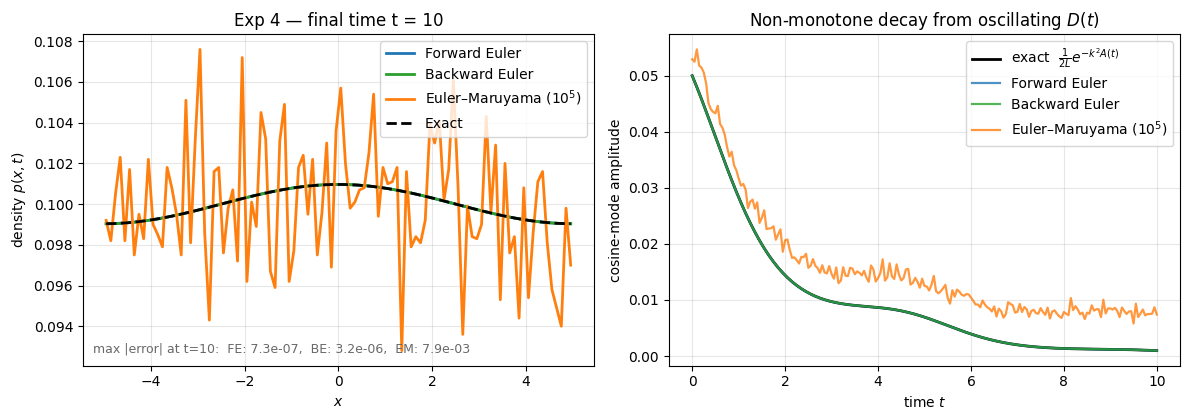

In [16]:
# Final-time comparison against the exact time-dependent solution, with a
# second panel showing the non-monotone amplitude decay: because D(t)
# oscillates, the accumulated diffusion A(t), and hence the mode
# amplitude 1/(2L) exp(-k^2 A(t)), grows in bursts rather than steadily.
errs4 = {m: float(np.max(np.abs(results4[m].snapshots[-1] - exact4(x4, 10.0))))
         for m in results4}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

for m in results4:
    ax1.plot(x4, results4[m].snapshots[-1], lw=2, **STYLE[m])
ax1.plot(x4, exact4(x4, 10.0), **EXACT_STYLE)
ax1.set_xlabel('$x$'); ax1.set_ylabel('density $p(x,t)$')
ax1.set_title('Exp 4 — final time t = 10')
ax1.grid(True, alpha=0.3); ax1.legend(loc='upper right')
ax1.text(0.02, 0.03, "max |error| at t=10:  " +
         ",  ".join(f"{m}: {errs4[m]:.1e}" for m in results4),
         transform=ax1.transAxes, fontsize=9, color='dimgray', va='bottom')

# Exact mode amplitude 1/(2L) e^{-k^2 A(t)} vs. the numerical amplitude
# (half the peak-to-peak of each method's frames), over time.
tt = results4['FE'].frame_times
ax2.plot(tt, 0.5 * np.exp(-K**2 * A_of_t(tt))/L, color='black', lw=2,
         label=r'exact  $\frac{1}{2L} e^{-k^2 A(t)}$')
for m in results4:
    amp = 0.5 * np.ptp(results4[m].frames, axis=1)
    ax2.plot(results4[m].frame_times, amp, lw=1.6, alpha=0.8, **STYLE[m])
ax2.set_xlabel('time $t$'); ax2.set_ylabel('cosine-mode amplitude')
ax2.set_title('Non-monotone decay from oscillating $D(t)$')
ax2.grid(True, alpha=0.3); ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Summary

| # | What it shows | Outcome |
|---|---|---|
| 1 | Diffusion only, all methods vs. exact | FE, BE match exact to $\sim10^{-6}$; EM to $\sim10^{-2}$ (histogram sampling noise, RMS $\sqrt{p/(N\Delta x)}$) |
| 2 | Separate CFLs pass, combined fails | FE diverges ($\sim10^{84}$, round-off-seeded, so only the exponent is reproducible); BE and EM stay bounded |
| 3 | Drift only at Courant $\lambda=1$ | FE transports **exactly** (amplitude preserved); BE shows numerical diffusion |
| 4 | Time-dependent $D(t)$ vs. exact | FE, BE match exact to $\sim10^{-6}$; EM to $\sim10^{-2}$; amplitude decay correctly non-monotone |

Two threads run through all four:

- **Finite volume vs. particle trade-off.** The two PDE methods are
  numerically exact up to discretization error (clean, smooth curves);
  Euler–Maruyama pays $O(1/\sqrt{N})$ statistical noise but needs no CFL
  condition and never differentiates the coefficients.

- **Stability is a combined property.** Experiment 2 is the concrete
  reminder that $\lambda + 2\mu \le 1$  (not the two separate CFLs) is
  what governs the explicit scheme, and Experiment 3 is the flip side:
  at $\lambda = 1$ the explicit upwind scheme is not just stable but
  *exact*, which the implicit scheme does not achieve. Moreover, the explicit scheme
  is exact at a precise value of $dt$ given $dx$, i.e. it is not always true that finer time steps
  yield better results.

## Playground — your own run

Everything above is fixed: four experiments chosen to make one point
each, against solutions known in closed form. This last cell is yours.

Default values produce the GIF at the beginning of the README: a Gaussian bump
advected twice around a periodic domain while it diffuses.

Two things happen before the solver does any work, mirroring the two
buttons of the GUI. The diagnostics block reports $\lambda$, $\mu$, the
combined stability number $\lambda + 2\mu$ and the cell Péclet number,
exactly as **Show diagnostics** would; and if Forward Euler has been
asked to run past its stability limit, the cell says so and runs anyway,
where the window would have stopped to ask. Nothing is written to disk:
the animation is assembled in memory and displayed below.

In [ ]:
###
# Playground: the GUI, as a cell.
#
# Every field of the Tkinter window appears below with the same name and
# the same default, and the run goes through the same `solve` the window
# calls. The diagnostics printed first are the ones behind the window's
# "Show diagnostics" button; the animation is built in memory and shown
# underneath, so each run produces a fresh GIF and nothing is written to
# disk.


import io
from IPython.display import Image
from PIL import Image as PILImage
from fp1d.api import _as_coefficient
from fp1d.grid import finite_domain

# --- the GUI's fields, verbatim ---------------------------------------
# Defaults reproduce the README's demo animation: a unit-speed drift
# carrying a Gaussian twice around the periodic domain (one lap takes
# L/b = 10 time units) with weak diffusion smoothing it as it goes.
method            = 'Forward Euler'      # Forward Euler | Backward Euler | Euler-Maruyama
left              = '-5'                 # a number, or '-inf'
right             = '5'                  # a number, or 'inf'
dx                = 0.02
T                 = 20.0
dt                = 0.004
trials            = 100_000              # Euler-Maruyama only
save              = [0, 20]
bc_type           = 'periodic'           # periodic | neumann | dirichlet
drift             = '1.0*np.ones(len(x))'
diffusivity       = '0.03*np.ones(len(x))'
initial_condition = 'custom'             # gaussian | uniform | bimodal | left-block | custom
custom_expr       = 'np.exp(-0.5*x**2/0.25)/np.sqrt(2*np.pi*0.25)'
seed              = 0

MAX_FRAMES, FPS, DPI = 45, 9, 72         # animation size/smoothness knobs
# --- stability check, before committing to a run -----------------------
# `_as_coefficient` is the same conversion `solve` applies to an
# expression string, so the diagnostics below describe exactly the run
# that follows rather than an approximation of it. With an infinite bound
# they are computed on a provisional truncation, since lambda and mu need
# a concrete grid; the adaptive loop may widen it, which changes max|b|
# and max D wherever the coefficients vary in x.
drift_fn = _as_coefficient(drift, 'drift')
diffusion_fn = _as_coefficient(diffusivity, 'diffusion')
probe_left, probe_right, trunc_msg = finite_domain(str(left), str(right), -5.0, 5.0)
probe_grid, dx_msg = make_grid(probe_left, probe_right, dx)
d = sample_diagnostics(probe_grid, drift_fn, diffusion_fn, dt, T)

for note in (trunc_msg, dx_msg):
    if note:
        print(note)
print(f"Grid:                  dx = {probe_grid.dx:.4g}, {probe_grid.ncells} cells, "
      f"domain = [{probe_grid.left:.4g}, {probe_grid.right:.4g}]")
print(f"Max |b(x,t)|:          {d['max_abs_b']:.4g}")
print(f"Max D(x,t):            {d['max_D']:.4g}")
print(f"Advective CFL, lambda: {d['lambda']:.4g}")
print(f"Diffusion number, mu:  {d['mu']:.4g}")
print(f"lambda + 2*mu:         {d['combined_CFL']:.4g}   "
      f"({'stable' if d['stable'] else 'UNSTABLE for Forward Euler'})")
print(f"Max Peclet number:     {d['Peclet']:.4g}")
print(f"Suggested FE dt <=     {d['dt_suggested']:.4g}")

if method == 'Forward Euler' and not d['stable']:
    print(f"\n!! lambda + 2*mu = {d['combined_CFL']:.4g} > 1: Forward Euler will "
          f"diverge. Reduce dt below {d['dt_suggested']:.4g}, or switch method.")
    print("   Running anyway - this is the cell the GUI would have asked "
          "you to confirm.")
print()

# --- run ---------------------------------------------------------------
run = solve(method=method, drift=drift, diffusion=diffusivity,
            left=left, right=right, dx=dx, total_time=T, dt=dt,
            save_times=save, bc=bc_type,
            initial_condition=initial_condition, custom_expr=custom_expr,
            trials=trials, seed=seed, on_warning='ignore')

result, grid_used, params = run.result, run.grid, run.parameters
for message in run.messages:
    print(message)
print(f"Method:       {method}")
print(f"Domain used:  [{grid_used.left:.6g}, {grid_used.right:.6g}]  "
      f"(dx = {grid_used.dx:.6g}, {grid_used.ncells} cells)")
print(f"Boundary:     {bc_type}")
print(f"Mass:         {result.masses[0]:.10f} -> {result.masses[-1]:.10f}")
print("Absorbed:     {:.4g}".format(params['absorbed_mass_fraction'])
      if bc_type == 'dirichlet' else
      "Max |mass-1|: {:.3e}".format(params['max_mass_deviation_from_1']))

# --- animate the frames the solver actually recorded -------------------
frames, times = result.frames, result.frame_times
idx = list(range(0, len(times), max(1, len(times) // MAX_FRAMES)))
if idx[-1] != len(times) - 1:
    idx.append(len(times) - 1)

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=DPI)
line, = ax.plot([], [], lw=2, color='tab:blue')
ax.set_xlim(result.x.min(), result.x.max())
# Fixed y-limits across the whole run, so the axis does not rescale from
# frame to frame and disguise what the density is doing.
top = float(np.max(frames))
ax.set_ylim(min(0.0, float(np.min(frames))), top * 1.15 if top > 0 else 1.0)
ax.set_xlabel('$x$')
ax.set_ylabel('density $p(x,t)$')
ax.grid(True, alpha=0.3)
heading = ax.set_title('')

# Rendered by hand rather than through FuncAnimation.save, which insists
# on a filename: each frame is drawn, grabbed off the canvas, and handed
# to Pillow, which assembles the GIF straight into a BytesIO.
shots = []
for i in idx:
    line.set_data(result.x, frames[i])
    heading.set_text(f'{method} — {bc_type}   (t = {times[i]:.4g})')
    fig.canvas.draw()
    shots.append(PILImage.fromarray(np.asarray(fig.canvas.buffer_rgba())).convert('RGB'))
plt.close(fig)

buffer = io.BytesIO()
shots[0].save(buffer, format='GIF', save_all=True, append_images=shots[1:],
              duration=int(1000 / FPS), loop=0, optimize=True)
Image(data=buffer.getvalue(), format='gif')